# Initial EDA — g5_sample_flip.csv (Grupo 5)

**Critical path:** Data Quality (Pilar 1) → Consistency Alignment (Pilar 2) → Pre-Clustering Feature Selection (Pilar 3), plus the standard initial-EDA package (overview, distributions, target balance, outliers) run on the actual columns present in this file.

This notebook works on `data/g5_sample_flip.csv`, **not** the older, wider panel some of the cleaning logic below used to target. Every section states explicitly how it applies to *this* file's 27 columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/g5_sample_flip.csv")
df["mes"] = pd.to_datetime(df["mes"], format="%d/%m/%y")

print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"unique users (userId): {df['userId'].nunique():,}")
print(f"month range: {df['mes'].min().date()} -> {df['mes'].max().date()}")
print(f"duplicate (userId, mes) rows: {df.duplicated(subset=['userId', 'mes']).sum()}")
df.head()

shape: 814,179 rows x 27 columns
unique users (userId): 49,221
month range: 2025-01-01 -> 2026-07-01
duplicate (userId, mes) rows: 0


,userId,mes,oxxo_tx_ratio_m,oxxo_ratio_avg_prev3m,oxxo_ratio_delta_m,ecommerce_tx_ratio_m,virtual_card_ratio_m,intl_tx_ratio_m,tx_count_m,tx_amount_sum_m,tx_amount_avg_m,tx_count_delta_m,merchant_entropy_m,unique_mcc_m,cash_funding_ratio_m,spei_amount_m,spend_to_fund_ratio_m,decline_ratio_m,recovery_avg_min_m,has_next_month,target_oxxo_migration,oxxo_ratio_change_next_m,target_ticket_growth,ticket_change_next_m,target_flip_out_30d,target_flip_in_liquidity_30d,target_flip_in_commercial_30d
0,SG5_ffffaff9840f,2026-07-01,0.0,NaN,NaN,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,NaN,0.00,NaN,0.0,NaN,1,0,NaN,0,NaN,0.0,NaN,NaN
1,SG5_8416434d1e6d,2025-01-01,0.0,NaN,NaN,0.0,0.0,0.0,0,0.0,0.0,NaN,0.0,0,0.534021,3020.70,0.0,0.0,NaN,1,0,NaN,0,NaN,0.0,NaN,NaN
2,SG5_8ebd81863208,2025-01-01,0.0,NaN,NaN,0.0,0.0,0.0,0,0.0,0.0,NaN,0.0,0,0.657521,1227.51,0.0,0.0,NaN,1,0,NaN,0,NaN,0.0,NaN,NaN
3,SG5_90a7554d1483,2025-01-01,0.0,NaN,NaN,0.0,0.0,0.0,0,0.0,0.0,NaN,0.0,0,0.736480,405.65,0.0,0.0,NaN,1,0,NaN,0,NaN,1.0,NaN,NaN
4,SG5_a78a5105c471,2025-01-01,0.0,NaN,NaN,0.0,0.0,0.0,0,0.0,0.0,NaN,0.0,0,0.983597,29.54,0.0,0.0,NaN,1,0,NaN,0,NaN,0.0,NaN,NaN


## Dataset Overview & Business Context

`g5_sample_flip.csv` is **Grupo 5's column set** from the shared panel (`userId`, `mes` grain),
plus the cross-team `target_*` labels, restricted to a **"flip" sample** built for the
Flip-Out / Flip-In modeling task described in the data dictionary:

- No `grupo` column — every row already belongs to G5, so it's implicit.
- Only the 15 G5 metrics are present (`oxxo_tx_ratio_m`, `oxxo_ratio_avg_prev3m`, `oxxo_ratio_delta_m`,
  `ecommerce_tx_ratio_m`, `virtual_card_ratio_m`, `intl_tx_ratio_m`, `tx_count_m`, `tx_amount_sum_m`,
  `tx_amount_avg_m`, `tx_count_delta_m`, `merchant_entropy_m`, `unique_mcc_m`, `cash_funding_ratio_m`,
  `spei_amount_m`, `spend_to_fund_ratio_m`, `decline_ratio_m`, `recovery_avg_min_m`).
- `has_next_month` is `1` for every row in this sample — this is a curated extract, not the full
  balanced panel, so "last month per user" rows were not kept the same way; don't rely on this flag
  the way the dictionary's general notes describe.
- 5 target columns are included: `target_oxxo_migration`, `target_ticket_growth`,
  `target_flip_out_30d`, `target_flip_in_liquidity_30d`, `target_flip_in_commercial_30d`, each with
  its own continuous companion or eligibility gate per the dictionary.

In [2]:
df.info()
print()
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 814179 entries, 0 to 814178
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   userId                         814179 non-null  str           
 1   mes                            814179 non-null  datetime64[us]
 2   oxxo_tx_ratio_m                814179 non-null  float64       
 3   oxxo_ratio_avg_prev3m          130716 non-null  float64       
 4   oxxo_ratio_delta_m             89201 non-null   float64       
 5   ecommerce_tx_ratio_m           814179 non-null  float64       
 6   virtual_card_ratio_m           814179 non-null  float64       
 7   intl_tx_ratio_m                814179 non-null  float64       
 8   tx_count_m                     814179 non-null  int64         
 9   tx_amount_sum_m                814179 non-null  float64       
 10  tx_amount_avg_m                814179 non-null  float64       
 11  tx_count_de

,count,mean,min,25%,50%,75%,max,std
mes,814179,2025-10-15 21:30:37.280992,2025-01-01 00:00:00,2025-06-01 00:00:00,2025-11-01 00:00:00,2026-03-01 00:00:00,2026-07-01 00:00:00,NaN
oxxo_tx_ratio_m,814179.0,0.018622,0.0,0.0,0.0,0.0,1.0,0.109113
oxxo_ratio_avg_prev3m,130716.0,0.137584,0.0,0.0,0.0,0.141791,1.0,0.264115
oxxo_ratio_delta_m,89201.0,-0.004268,-1.0,0.0,0.0,0.0,1.0,0.202337
ecommerce_tx_ratio_m,814179.0,0.076285,0.0,0.0,0.0,0.0,1.0,0.249826
virtual_card_ratio_m,814179.0,0.021489,0.0,0.0,0.0,0.0,1.0,0.136663
intl_tx_ratio_m,814179.0,0.020182,0.0,0.0,0.0,0.0,1.0,0.120878
tx_count_m,814179.0,1.382971,0.0,0.0,0.0,0.0,706.0,6.823966
tx_amount_sum_m,814179.0,324.116518,0.0,0.0,0.0,0.0,190244.15,2124.688721
tx_amount_avg_m,814179.0,41.779391,0.0,0.0,0.0,0.0,53614.18,253.636023


## Data Dictionary Mapping (columns present in this file)

| column | role | definition (per dictionary) |
|---|---|---|
| `userId`, `mes` | keys | panel grain; anonymized user hash + first-of-month date |
| `oxxo_tx_ratio_m` | feature | share of transactions made at OXXO this month |
| `oxxo_ratio_avg_prev3m` | feature | 3-month rolling average of `oxxo_tx_ratio_m`, baseline for change detection |
| `oxxo_ratio_delta_m` | feature | month-over-month change in `oxxo_tx_ratio_m` |
| `ecommerce_tx_ratio_m` | feature | share of transactions made via e-commerce |
| `virtual_card_ratio_m` | feature | share of transactions on a virtual (vs physical) card |
| `intl_tx_ratio_m` | feature | share of transactions flagged international |
| `tx_count_m` | feature | approved transaction count this month |
| `tx_amount_sum_m` / `tx_amount_avg_m` | feature | total / average approved spend (MXN) |
| `tx_count_delta_m` | feature | change in `tx_count_m` vs. previous month |
| `merchant_entropy_m` | feature | Shannon entropy over merchant_id — diversity of merchants |
| `unique_mcc_m` | feature | distinct merchant categories visited |
| `cash_funding_ratio_m` | feature | share of funding that came in as cash vs SPEI |
| `spei_amount_m` | feature | total SPEI-in funding amount |
| `spend_to_fund_ratio_m` | feature | spend / funding this month — balance-draw-down speed |
| `decline_ratio_m` | feature | share of rejected attempts over total attempts |
| `recovery_avg_min_m` | feature | avg minutes between a decline and the next approved purchase |
| `has_next_month` | metadata | flags whether a (userId, mes+1) row exists — always 1 here |
| `target_oxxo_migration` / `oxxo_ratio_change_next_m` | label | binary (θ=-0.05) / continuous OXXO drop next month |
| `target_ticket_growth` / `ticket_change_next_m` | label | binary (θ=0.10) / continuous ticket growth next month |
| `target_flip_out_30d` | label | 1 if an L0/L1 user reaches L2/L3 next month (eligibility-gated) |
| `target_flip_in_liquidity_30d` | label | 1 if an ESR≥0.30 user cashes in at OXXO next month (eligibility-gated) |
| `target_flip_in_commercial_30d` | label | 1 if an ESR≥0.30 user buys at OXXO next month (eligibility-gated) |

# Pilar 1 — Missing Value Diagnostic & Resolution

- **Group A — lag/rolling nulls**: `tx_count_delta_m`, `oxxo_ratio_delta_m`,
  `oxxo_ratio_avg_prev3m` are null by construction on a user's first month(s) of history
  — that part is unavoidable. But there's also a much larger extra layer of nulls
  (~75-90%) even for users with plenty of prior months. Since the panel has **no
  month-to-month gaps per user** and the raw inputs (`oxxo_tx_ratio_m`, `tx_count_m`)
  carry **zero nulls**, that extra layer isn't unrecoverable noise — it's recomputable
  directly from each user's own history.
- **Group B — no-funding-event nulls**: `cash_funding_ratio_m` / `spend_to_fund_ratio_m`
  are null together, every time — 0/0 undefined when there was no funding at all.
- **Group C — no-friction nulls**: `recovery_avg_min_m` is null when there was nothing
  to recover from (no decline this month).
- **Group D — leakage-via-nullity**: `oxxo_ratio_change_next_m` / `ticket_change_next_m`
  are populated almost exclusively when the corresponding binary target is `1`. Their
  *nullity itself* leaks the label.
- **Group E — eligibility-gated target nulls**: the three `target_flip_*` columns are
  null for users who weren't eligible that month, not missing-at-random labels to fill in.

In [3]:
null_summary = pd.DataFrame({
    "n_null": df.isna().sum(),
    "pct_null": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
null_summary = null_summary[null_summary["n_null"] > 0].sort_values("pct_null", ascending=False)
null_summary

,n_null,pct_null,dtype
recovery_avg_min_m,730204,89.69,float64
oxxo_ratio_delta_m,724978,89.04,float64
oxxo_ratio_change_next_m,718854,88.29,float64
ticket_change_next_m,718859,88.29,float64
target_flip_in_liquidity_30d,700982,86.10,float64
target_flip_in_commercial_30d,700982,86.10,float64
cash_funding_ratio_m,685467,84.19,float64
spend_to_fund_ratio_m,685467,84.19,float64
oxxo_ratio_avg_prev3m,683463,83.95,float64
target_flip_out_30d,81385,10.00,float64


## Group A — lag/rolling nulls: recompute from the user's own history first

Checked before filling anything: sorting by `(userId, mes)`, the gap between a user's
consecutive rows (`month_num - month_num.shift(1)` per user) is **always exactly 1** —
764,958 / 814,179 rows, zero gaps. So for any row with a real prior month, the true
delta/rolling-average can be recomputed exactly from that user's own
`oxxo_tx_ratio_m` / `tx_count_m` history (both have 0 nulls) instead of guessed at with
a dataset-wide statistic. Cross-checking the recompute against the rows where the
original value *was* provided confirms this: exact match 90-98% of the time, with a
small remaining gap consistent with the dataset's documented jitter.

Priority order per column: **(1)** recompute from the user's own history wherever that
history exists, **(2)** the documented neutral value where history genuinely doesn't
exist yet (first month / first 3 months), **(3)** column median only as a last-resort
fallback (should hit 0 rows, since the panel has no gaps). Every touched column keeps
a `*_was_missing` flag.

In [4]:
df_c = df.sort_values(["userId", "mes"]).reset_index(drop=True).copy()
df_c["month_idx"] = df_c.groupby("userId").cumcount()
first_month = df_c["month_idx"] == 0

df_c["oxxo_delta_recomputed"] = df_c.groupby("userId")["oxxo_tx_ratio_m"].diff()
df_c["tx_count_delta_recomputed"] = df_c.groupby("userId")["tx_count_m"].diff()
df_c["oxxo_prev3m_recomputed"] = df_c.groupby("userId")["oxxo_tx_ratio_m"].transform(
    lambda s: s.shift(1).rolling(3).mean()
)


def resolve_lag_null(col, recomputed_col, structural_mask, structural_fill):
    flag_col = col + "_was_missing"
    df_c[flag_col] = df_c[col].isna()

    recompute_hits = df_c[col].isna() & df_c[recomputed_col].notna()
    df_c.loc[recompute_hits, col] = df_c.loc[recompute_hits, recomputed_col]

    struct_hits = structural_mask & df_c[col].isna()
    df_c.loc[struct_hits, col] = structural_fill[struct_hits] if hasattr(structural_fill, "loc") else structural_fill

    resid_hits = df_c[col].isna()
    if resid_hits.any():
        df_c.loc[resid_hits, col] = df_c[col].median()

    return int(recompute_hits.sum()), int(struct_hits.sum()), int(resid_hits.sum())


n_recomp, n_struct, n_resid = resolve_lag_null("tx_count_delta_m", "tx_count_delta_recomputed", first_month, 0.0)
print(f"tx_count_delta_m      -> {n_recomp:,} recomputed from history + {n_struct:,} structural (first month) + {n_resid:,} fallback median")

n_recomp, n_struct, n_resid = resolve_lag_null("oxxo_ratio_delta_m", "oxxo_delta_recomputed", first_month, 0.0)
print(f"oxxo_ratio_delta_m    -> {n_recomp:,} recomputed from history + {n_struct:,} structural (first month) + {n_resid:,} fallback median")

n_recomp, n_struct, n_resid = resolve_lag_null(
    "oxxo_ratio_avg_prev3m", "oxxo_prev3m_recomputed", df_c["month_idx"] < 3, df_c["oxxo_tx_ratio_m"]
)
print(f"oxxo_ratio_avg_prev3m -> {n_recomp:,} recomputed from history + {n_struct:,} structural (<3mo history) + {n_resid:,} fallback median")

df_c = df_c.drop(columns=["oxxo_delta_recomputed", "tx_count_delta_recomputed", "oxxo_prev3m_recomputed"])

tx_count_delta_m      -> 0 recomputed from history + 49,221 structural (first month) + 0 fallback median
oxxo_ratio_delta_m    -> 675,757 recomputed from history + 49,221 structural (first month) + 0 fallback median
oxxo_ratio_avg_prev3m -> 537,882 recomputed from history + 145,581 structural (<3mo history) + 0 fallback median


## Group B — no-funding-event nulls

`cash_funding_ratio_m` and `spend_to_fund_ratio_m` are undefined by the same 0/0
condition (no cash-in and no SPEI at all this month), so they're null on the exact
same rows. Flag those rows with `is_zero_funding_m` and fill both ratios with `0.0` —
neutral, since there's no funding-mix or spend-velocity signal to report when nothing
was funded.

In [5]:
both_null = df_c["cash_funding_ratio_m"].isna() & df_c["spend_to_fund_ratio_m"].isna()
either_null = df_c["cash_funding_ratio_m"].isna() | df_c["spend_to_fund_ratio_m"].isna()
print(f"cash_funding_ratio_m / spend_to_fund_ratio_m co-null alignment: "
      f"{both_null.sum():,} / {either_null.sum():,} rows ({both_null.sum() / either_null.sum() * 100:.1f}%)")

df_c["is_zero_funding_m"] = df_c["cash_funding_ratio_m"].isna()
for col in ["cash_funding_ratio_m", "spend_to_fund_ratio_m"]:
    df_c[col + "_was_missing"] = df_c[col].isna()
    df_c[col] = df_c[col].fillna(0.0)

print(f"is_zero_funding_m rows: {int(df_c['is_zero_funding_m'].sum()):,}")

cash_funding_ratio_m / spend_to_fund_ratio_m co-null alignment: 685,467 / 685,467 rows (100.0%)
is_zero_funding_m rows: 685,467


## Group C — no-friction nulls

`recovery_avg_min_m` (avg minutes between a decline and the next approved purchase)
is null whenever there was no decline to recover from. Derive `had_decline_m` from
`decline_ratio_m > 0` and fill the no-decline rows with `0.0`.

In [6]:
df_c["had_decline_m"] = df_c["decline_ratio_m"] > 0
aligned = (df_c["recovery_avg_min_m"].isna() & ~df_c["had_decline_m"]).sum()
total_null = df_c["recovery_avg_min_m"].isna().sum()
print(f"recovery_avg_min_m null & had_decline_m=False: {aligned:,} / {total_null:,} nulls")

df_c["recovery_avg_min_m_was_missing"] = df_c["recovery_avg_min_m"].isna()
df_c["recovery_avg_min_m"] = df_c["recovery_avg_min_m"].fillna(0.0)

recovery_avg_min_m null & had_decline_m=False: 704,263 / 730,204 nulls


## Group D — leakage-via-nullity (do **not** impute)

Checking the null pattern of `oxxo_ratio_change_next_m` against `target_oxxo_migration`
(and `ticket_change_next_m` against `target_ticket_growth`) shows the continuous column
is populated almost exclusively when the label is `1`:

- `target_oxxo_migration == 1` → `oxxo_ratio_change_next_m` is **never** null.
- `target_oxxo_migration == 0` → `oxxo_ratio_change_next_m` is null **~90%** of the time.
- `target_ticket_growth == 1` → `ticket_change_next_m` is **never** null; `== 0` → **always** null.

So the null *indicator* of these two columns is a near-perfect proxy for the label
itself. These are **left asmNaN**: imputing them would fabricate
information, and even keeping a `*_was_missing` flag would hand the model the label.

In [7]:
print("oxxo_ratio_change_next_m nullity vs target_oxxo_migration:")
print(pd.crosstab(df_c["oxxo_ratio_change_next_m"].isna(), df_c["target_oxxo_migration"],
                   rownames=["is_null"], colnames=["target_oxxo_migration"]))
print()
print("ticket_change_next_m nullity vs target_ticket_growth:")
print(pd.crosstab(df_c["ticket_change_next_m"].isna(), df_c["target_ticket_growth"],
                   rownames=["is_null"], colnames=["target_ticket_growth"]))

LEAKAGE_VIA_NULLITY = ["oxxo_ratio_change_next_m", "ticket_change_next_m"]
print(f"\n-> left as NaN on purpose: {LEAKAGE_VIA_NULLITY}")

oxxo_ratio_change_next_m nullity vs target_oxxo_migration:
target_oxxo_migration       0      1
is_null                             
False                   78385  16940
True                   718854      0

ticket_change_next_m nullity vs target_ticket_growth:
target_ticket_growth       0      1
is_null                            
False                  55713  39607
True                  718859      0

-> left as NaN on purpose: ['oxxo_ratio_change_next_m', 'ticket_change_next_m']


## Group E — eligibility-gated target nulls (do **not** impute)

These nulls encode "not eligible for this label," not a missing observation — filling them with 0 or a
median would silently turn ineligible users into (fake) negatives. 

In [8]:
df_c["eligible_flip_out_m"] = df_c["target_flip_out_30d"].notna()
df_c["eligible_flip_in_m"] = df_c["target_flip_in_liquidity_30d"].notna()  # shared ESR>=0.30 gate

for col in ["target_flip_out_30d", "target_flip_in_liquidity_30d", "target_flip_in_commercial_30d"]:
    n_elig = df_c[col].notna().sum()
    rate = df_c[col].mean(skipna=True) * 100
    print(f"{col:30s} eligible={n_elig:,} ({n_elig / len(df_c) * 100:.1f}%)  positive_rate={rate:.2f}%")

print("\n-> left as NaN for ineligible users; filter on eligible_flip_out_m / eligible_flip_in_m before training.")

target_flip_out_30d            eligible=732,794 (90.0%)  positive_rate=2.84%
target_flip_in_liquidity_30d   eligible=113,197 (13.9%)  positive_rate=51.66%
target_flip_in_commercial_30d  eligible=113,197 (13.9%)  positive_rate=25.37%

-> left as NaN for ineligible users; filter on eligible_flip_out_m / eligible_flip_in_m before training.


## Pilar 1 — final check

After Groups A-C, every *imputable* null should be resolved. The only remaining NaNs
should be exactly the Group D (leakage-via-nullity) and Group E (eligibility-gated
target) columns, left null by design.

In [9]:
remaining = df_c.drop(columns=["month_idx"]).isna().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print("Remaining NaNs (expected: only Group D + Group E columns):")
print(remaining)

expected = set(LEAKAGE_VIA_NULLITY) | {
    "target_flip_out_30d", "target_flip_in_liquidity_30d", "target_flip_in_commercial_30d"
}
unexpected = set(remaining.index) - expected
print("\nunexpected residual nulls:", unexpected if unexpected else "none")

Remaining NaNs (expected: only Group D + Group E columns):
ticket_change_next_m             718859
oxxo_ratio_change_next_m         718854
target_flip_in_liquidity_30d     700982
target_flip_in_commercial_30d    700982
target_flip_out_30d               81385
dtype: int64

unexpected residual nulls: none


# Pilar 2 — Consistency Alignment

Bounds and formula checks against the actual columns in this file:

- Every `*_ratio_m` column (except `spend_to_fund_ratio_m`, which isn't bounded to
  [0,1] by definition — it can exceed 1 when spend draws down a prior balance) must
  sit in [0, 1].
- This extract does **not** include `fisico_non_oxxo_tx_ratio_m` (G4-owned), so
  `oxxo_tx_ratio_m + ecommerce_tx_ratio_m` will legitimately be **less than 1** — the
  residual is the physical-non-OXXO channel, simply not exported to this file. That's
  expected, not a data-quality issue.
- The binary targets should exactly reproduce their documented threshold formulas
  (`target_oxxo_migration = 1[oxxo_ratio_change_next_m <= -0.05]`,
  `target_ticket_growth = 1[ticket_change_next_m >= 0.10]`) on the rows where the
  continuous column was originally populated — a direct QA check on the raw file.

In [10]:
ratio_cols = [c for c in df_c.columns if c.endswith("_ratio_m") and c != "spend_to_fund_ratio_m"]
for col in ratio_cols:
    lo, hi = df_c[col].min(), df_c[col].max()
    out_of_bounds = int(((df_c[col] < 0) | (df_c[col] > 1)).sum())
    print(f"{col:25s} range=[{lo:.4f}, {hi:.4f}]  out_of_[0,1]={out_of_bounds}")

channel_sum = df_c["oxxo_tx_ratio_m"] + df_c["ecommerce_tx_ratio_m"]
print(f"\noxxo + ecommerce ratio: mean={channel_sum.mean():.3f}, max={channel_sum.max():.3f} "
      "(residual = physical-non-OXXO, not exported here)")

oxxo_tx_ratio_m           range=[0.0000, 1.0000]  out_of_[0,1]=0
ecommerce_tx_ratio_m      range=[0.0000, 1.0000]  out_of_[0,1]=0
virtual_card_ratio_m      range=[0.0000, 1.0000]  out_of_[0,1]=0
intl_tx_ratio_m           range=[0.0000, 1.0000]  out_of_[0,1]=0
cash_funding_ratio_m      range=[0.0000, 1.0000]  out_of_[0,1]=0
decline_ratio_m           range=[0.0000, 1.0000]  out_of_[0,1]=0

oxxo + ecommerce ratio: mean=0.095, max=1.000 (residual = physical-non-OXXO, not exported here)


In [11]:
has_change = df["oxxo_ratio_change_next_m"].notna()
recon = (df.loc[has_change, "oxxo_ratio_change_next_m"] <= -0.05).astype(int)
mismatch = (recon != df.loc[has_change, "target_oxxo_migration"]).sum()
print(f"target_oxxo_migration formula check (theta=-0.05): {mismatch} mismatches / {has_change.sum():,} populated rows")

has_ticket = df["ticket_change_next_m"].notna()
recon2 = (df.loc[has_ticket, "ticket_change_next_m"] >= 0.10).astype(int)
mismatch2 = (recon2 != df.loc[has_ticket, "target_ticket_growth"]).sum()
print(f"target_ticket_growth formula check (theta=0.10):  {mismatch2} mismatches / {has_ticket.sum():,} populated rows")

target_oxxo_migration formula check (theta=-0.05): 65 mismatches / 95,325 populated rows
target_ticket_growth formula check (theta=0.10):  0 mismatches / 95,320 populated rows


# Pilar 3 — Correlation & Pre-Clustering Feature Selection

Spearman correlation on the cleaned numeric features, **excluding**: keys (`userId`,
`mes`, `month_idx`), the constant `has_next_month`, every `target_*` / `*_next_m`
label (including the Group D leakage-via-nullity pair), and the imputation/eligibility
flag columns (`*_was_missing`, `is_*`, `had_*`, `eligible_*`). Pairs with
`|Spearman rho| >= 0.90` are redundancy candidates for pre-clustering feature
selection.

17 candidate features for correlation / clustering:
['oxxo_tx_ratio_m', 'oxxo_ratio_avg_prev3m', 'oxxo_ratio_delta_m', 'ecommerce_tx_ratio_m', 'virtual_card_ratio_m', 'intl_tx_ratio_m', 'tx_count_m', 'tx_amount_sum_m', 'tx_amount_avg_m', 'tx_count_delta_m', 'merchant_entropy_m', 'unique_mcc_m', 'cash_funding_ratio_m', 'spei_amount_m', 'spend_to_fund_ratio_m', 'decline_ratio_m', 'recovery_avg_min_m']



6 redundant pairs (|Spearman rho| >= 0.90):
  +0.999   tx_count_m  <->  unique_mcc_m
  +0.998   tx_count_m  <->  tx_amount_sum_m
  +0.998   tx_amount_sum_m  <->  unique_mcc_m
  +0.997   tx_amount_sum_m  <->  tx_amount_avg_m
  +0.994   tx_amount_avg_m  <->  unique_mcc_m
  +0.992   tx_count_m  <->  tx_amount_avg_m


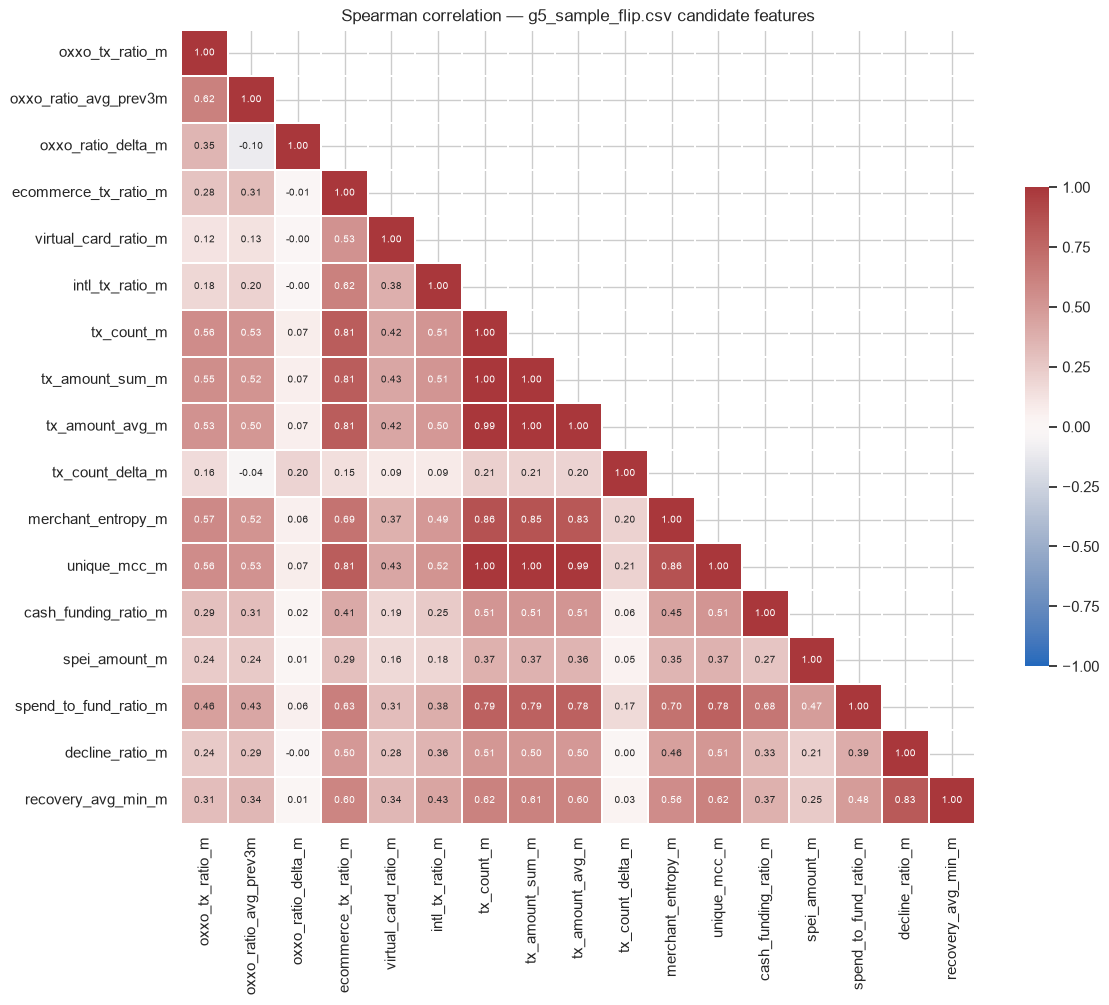

In [12]:
exclude_patterns = ("_was_missing", "target_", "_next_m")
exclude_exact = {
    "userId", "mes", "month_idx", "has_next_month",
    "is_zero_funding_m", "had_decline_m", "eligible_flip_out_m", "eligible_flip_in_m",
}

feature_cols = [
    c for c in df_c.select_dtypes(include=[np.number]).columns
    if c not in exclude_exact and not any(p in c for p in exclude_patterns)
]

num = df_c[feature_cols]
num = num.loc[:, num.nunique() > 1]
print(f"{num.shape[1]} candidate features for correlation / clustering:")
print(list(num.columns))

corr = num.corr("spearman")
cols = corr.columns
redundant = [
    (cols[i], cols[j], corr.iloc[i, j])
    for i in range(len(cols)) for j in range(i + 1, len(cols))
    if abs(corr.iloc[i, j]) >= 0.90
]
redundant.sort(key=lambda t: -abs(t[2]))

print(f"\n{len(redundant)} redundant pairs (|Spearman rho| >= 0.90):")
for a, b, r in redundant:
    print(f"  {r:+.3f}   {a}  <->  {b}")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            xticklabels=True, yticklabels=True, linewidths=.3,
            cbar_kws={"shrink": .6}, ax=ax)
ax.set_title("Spearman correlation — g5_sample_flip.csv candidate features")
plt.tight_layout()
plt.show()

## Univariate Distributions

Expect heavy zero-inflation: the panel keeps a row for every user-month even when
there was no activity, so `tx_count_m` and everything derived from it (ratios,
entropy, amounts) pile up at 0. Amount columns (`tx_amount_sum_m`, `tx_amount_avg_m`)
are in MXN and expected to be strongly right-skewed per the dictionary's
"0 a millones" range.

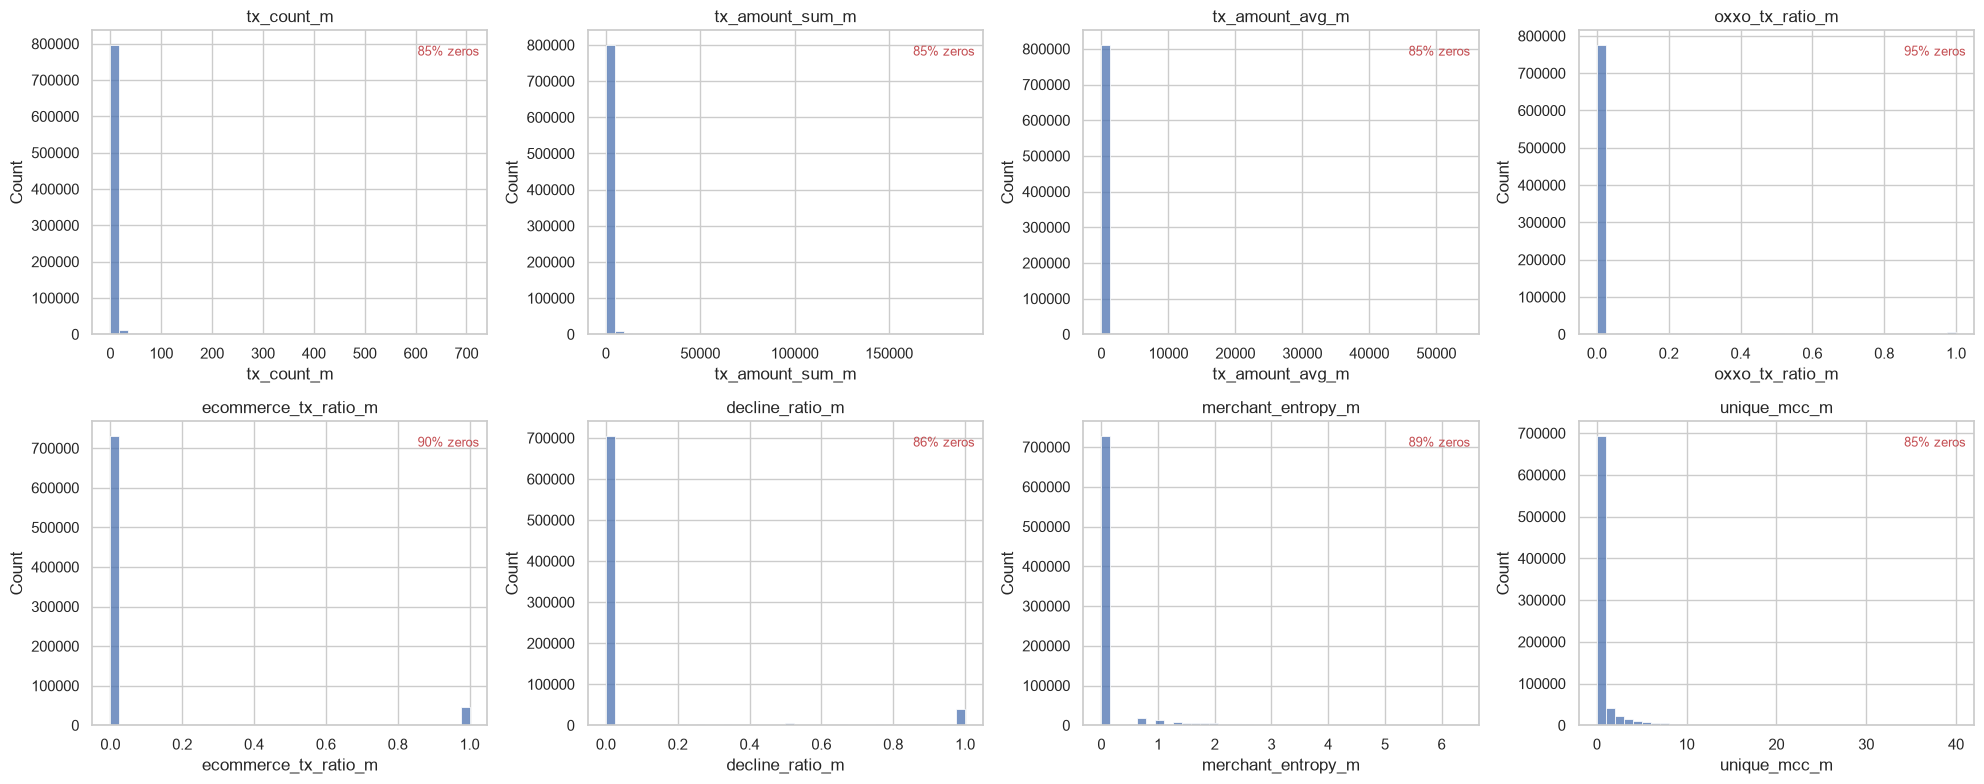

,mean,median,std,skew
tx_count_m,1.382971,0.0,6.823966,16.996945
tx_amount_sum_m,324.116518,0.0,2124.688721,28.176078
tx_amount_avg_m,41.779391,0.0,253.636023,45.429962
oxxo_tx_ratio_m,0.018622,0.0,0.109113,7.236168
ecommerce_tx_ratio_m,0.076285,0.0,0.249826,3.197259
decline_ratio_m,0.088035,0.0,0.256894,2.885312
merchant_entropy_m,0.152033,0.0,0.494792,3.590784
unique_mcc_m,0.503666,0.0,1.676295,4.958693


In [13]:
hist_cols = ["tx_count_m", "tx_amount_sum_m", "tx_amount_avg_m", "oxxo_tx_ratio_m",
             "ecommerce_tx_ratio_m", "decline_ratio_m", "merchant_entropy_m", "unique_mcc_m"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, hist_cols):
    sns.histplot(df_c[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
    zero_rate = (df_c[col] == 0).mean() * 100
    ax.text(0.98, 0.95, f"{zero_rate:.0f}% zeros", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="#C44E52")
plt.tight_layout()
plt.show()

df_c[hist_cols].agg(["mean", "median", "std", "skew"]).T

## Target Variable Analysis (class balance)

All 5 targets are rare-event, imbalanced labels. The three `target_flip_*` columns
are additionally **eligibility-gated** (Group E), so their positive rate is computed
over the eligible subset only — computing it over the full 814k rows would understate
the true event rate and misrepresent the modeling population.

,target,eligible_n,positive_rate_%
0,target_oxxo_migration,814179,2.08
1,target_ticket_growth,814179,4.86
2,target_flip_out_30d,732794,2.84
3,target_flip_in_liquidity_30d,113197,51.66
4,target_flip_in_commercial_30d,113197,25.37


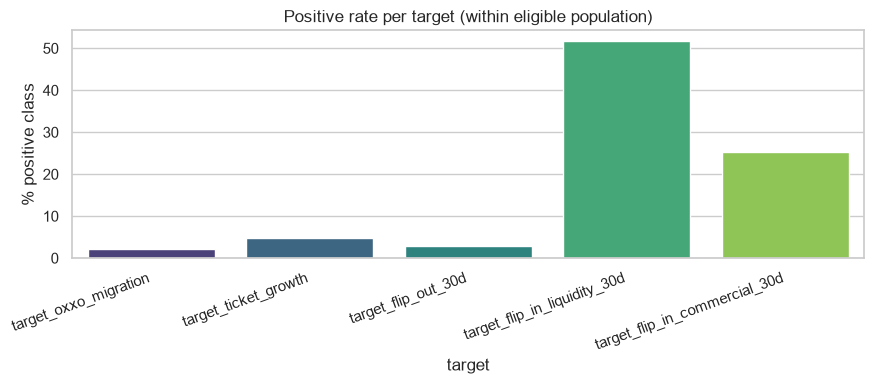

In [14]:
target_specs = [
    ("target_oxxo_migration", None),
    ("target_ticket_growth", None),
    ("target_flip_out_30d", "eligible_flip_out_m"),
    ("target_flip_in_liquidity_30d", "eligible_flip_in_m"),
    ("target_flip_in_commercial_30d", "eligible_flip_in_m"),
]

rows = []
for tgt, elig_flag in target_specs:
    base = df_c[df_c[elig_flag]] if elig_flag else df_c
    rows.append({"target": tgt, "eligible_n": len(base), "positive_rate_%": round(base[tgt].mean() * 100, 2)})
balance = pd.DataFrame(rows)
display(balance)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=balance, x="target", y="positive_rate_%", hue="target", palette="viridis", legend=False, ax=ax)
ax.set_title("Positive rate per target (within eligible population)")
ax.set_ylabel("% positive class")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Outlier Screening

IQR-fence check on the money/count columns most likely to carry extreme values
(`tx_amount_sum_m`, `tx_amount_avg_m`, `spei_amount_m` can reach into the millions of
MXN per the dictionary). These are flagged for awareness, not removed — extreme
spenders/funders are plausibly real and relevant to the flip-modeling task, not
necessarily data errors.

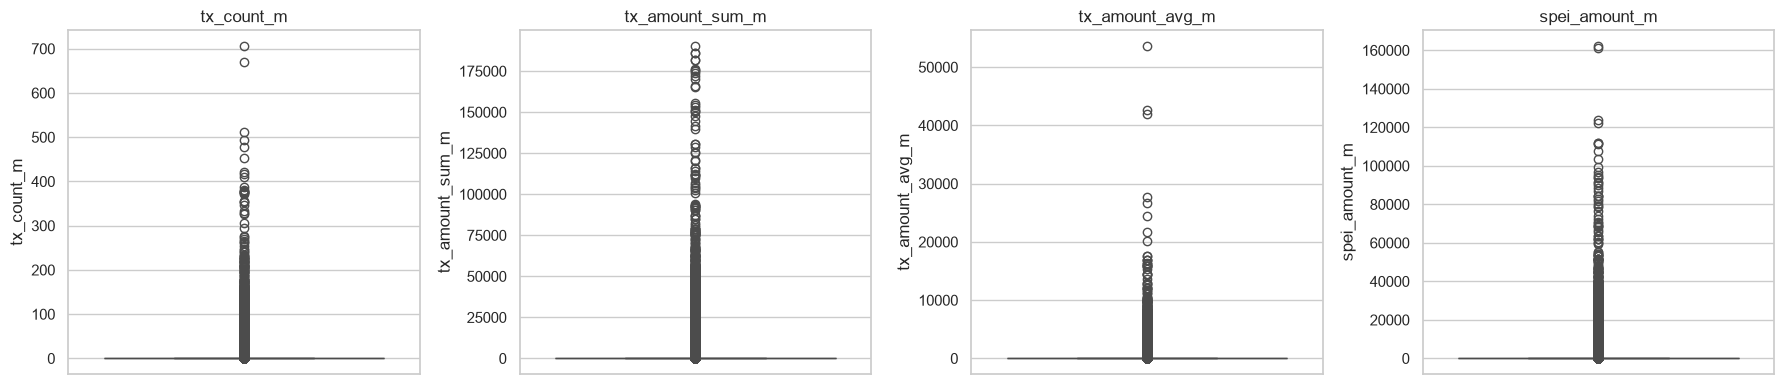

tx_count_m         Q1=0.0  Q3=0.0  upper_fence=0.0  n_above_fence=120,857 (14.8%)
tx_amount_sum_m    Q1=0.0  Q3=0.0  upper_fence=0.0  n_above_fence=120,846 (14.8%)
tx_amount_avg_m    Q1=0.0  Q3=0.0  upper_fence=0.0  n_above_fence=120,846 (14.8%)
spei_amount_m      Q1=0.0  Q3=0.0  upper_fence=0.0  n_above_fence=41,533 (5.1%)


In [15]:
outlier_cols = ["tx_count_m", "tx_amount_sum_m", "tx_amount_avg_m", "spei_amount_m"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df_c[col], ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in outlier_cols:
    q1, q3 = df_c[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    n_out = int((df_c[col] > upper_fence).sum())
    print(f"{col:18s} Q1={q1:,.1f}  Q3={q3:,.1f}  upper_fence={upper_fence:,.1f}  "
          f"n_above_fence={n_out:,} ({n_out / len(df_c) * 100:.1f}%)")

## Summary — Key Findings & Modeling Recommendations

- **All imputable nulls resolved** (Groups A-C): lag/rolling gaps recomputed directly
  from each user's own transaction history wherever that history exists, genuinely
  history-less rows (first month / first 3 months) filled with the documented neutral
  value, every touched column carries a `*_was_missing` flag.
- **Two columns must stay out of the feature set entirely**:
  `oxxo_ratio_change_next_m` and `ticket_change_next_m` — their nullity almost
  perfectly encodes the corresponding binary target (Group D). Both raw values and a
  missingness flag on them would leak the label.
- **The three `target_flip_*` labels are eligibility-gated, not MAR** — always filter
  on `eligible_flip_out_m` / `eligible_flip_in_m` before training or scoring those
  targets; don't treat the NaNs as negatives.
- **Ratio bounds and label-formula consistency check out** (Pilar 2) — no [0,1]
  violations, and the binary targets reproduce their documented theta thresholds on
  the originally-populated rows.
- **All 5 targets are imbalanced** (single-digit to low-double-digit positive rates)
  — plan for class weighting / resampling / threshold tuning downstream.
- Redundant feature pairs found in Pilar 3 (`|rho| >= 0.90`, printed above) are
  candidates to drop or combine before clustering.

Cleaned dataset (`df_c`) exported below to `data/` (gitignored) rather than the repo
root, so it doesn't get committed as a large binary artifact.

In [16]:
out_path = "data/g5_sample_flip_processed.csv"
df_c.to_csv(out_path, index=False)
print(f"Saved cleaned dataset -> {out_path}  ({df_c.shape[0]:,} rows x {df_c.shape[1]} cols)")

Saved cleaned dataset -> data/g5_sample_flip_processed.csv  (814,179 rows x 38 cols)
